## SARIMAX

**Objetivo:** desenvolver um modelo de previsão de PM2.5 utilizando SARIMAX, incorporando variáveis meteorológicas e sazonalidades temporais para previsão das próximas 24 horas.

**Objetivos específicos**:

- Avaliar o melhor experimento do Sarimax considerando o melhor conjunto de dados:

      - 100% dos dados entre 2016-2019, features (temp, umi, prec, wind), sem interpolação
      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
      - test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00

- Problemática: O desempenho do Sarimax está piorando muito na reprodução dos meses de inverno, serão testadas algumas configurações no modelo melhor ajustado para tentar capturar a sazonalidade.

- Experimentos realizados:

      - Controle: features - temp, umi, prec, wind
      - Experimento 01: features - temp, umi, prec, wind + componentes anuais de Fourier
      - Experimento 02: features - temp, umi, prec, wind + month, day, hour em componentes cíclicas 
      - Experimento 03: features - temp, umi, prec, wind + order(1,0,1)

### 1. Carregamento dos Experimentos

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
controle_val = pd.read_csv('../results/walk_forward_parcial_temp_umi_prec_wind_val.csv')
fourier_val = pd.read_csv('../results/walk_forward_completo_fourier_val.csv')
sincos_val = pd.read_csv('../results/walk_forward_parcial_sazonal_sincos_val.csv')
order_val = pd.read_csv('../results/walk_forward_parcial_temp_umi_prec_wind_101_val.csv')

### 2. Comparação dos experimentos

In [16]:
experimentos = {
    "controle": controle_val,
    "fourier": fourier_val,
    "sincos": sincos_val,
    "order_101": order_val
}

dfs = []

for nome, df in experimentos.items():
    df = df.copy()

    df["inicio_previsao"] = pd.to_datetime(df["inicio_previsao"])

    if "mae_sarimax" not in df.columns:
        df["mae_sarimax"] = df["mae"]
        df["rmse_sarimax"] = df["rmse"]
        df["r2_sarimax"] = df["r2"]

    df["experimento"] = nome

    dfs.append(
        df[[
            "experimento",
            "inicio_previsao",
            "mae_sarimax",
            "rmse_sarimax",
            "r2_sarimax"
        ]]
    )

df_exp = pd.concat(dfs, ignore_index=True)

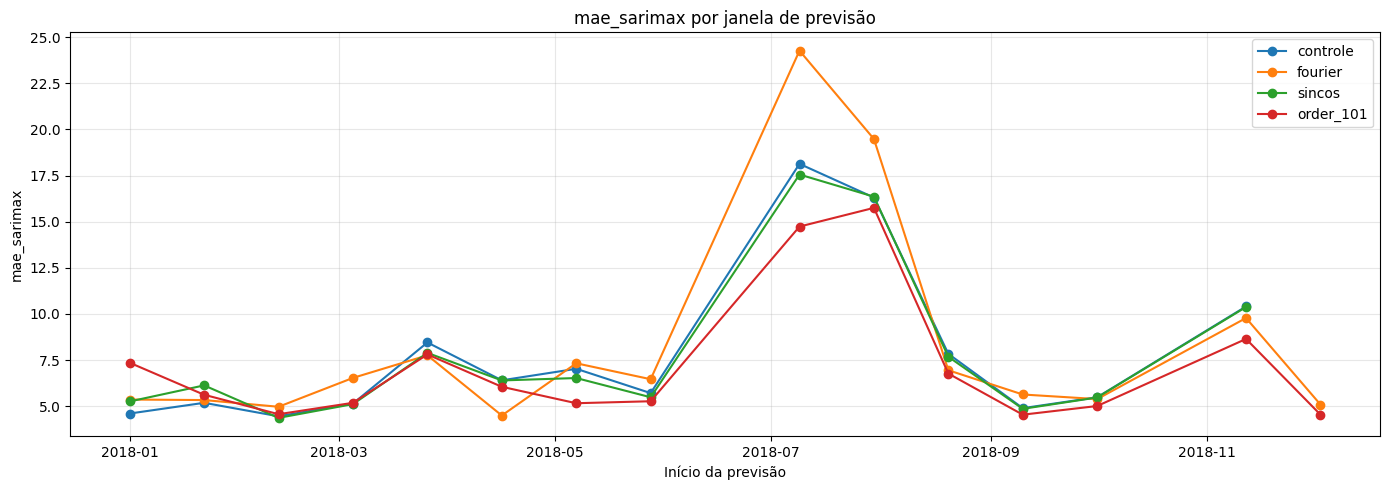

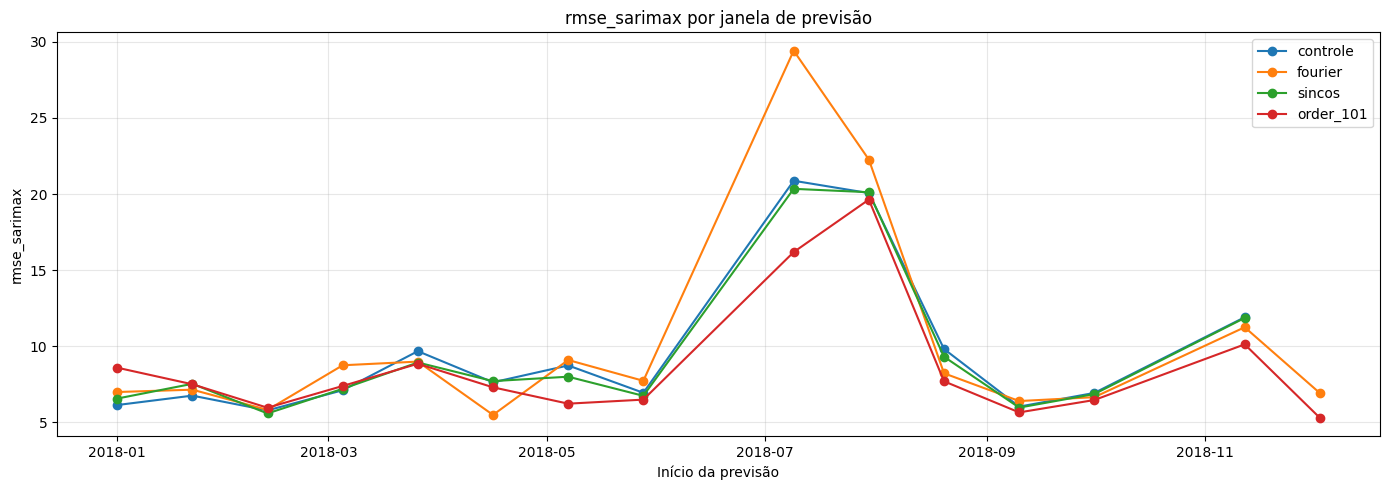

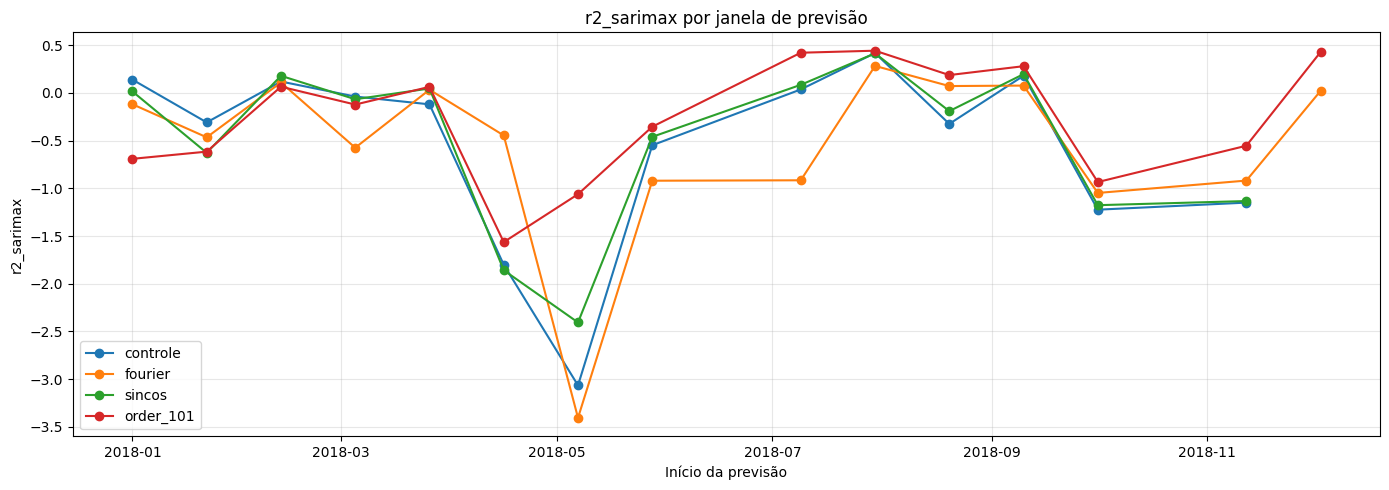

In [17]:
metricas = ["mae_sarimax", "rmse_sarimax", "r2_sarimax"]

for metrica in metricas:

    plt.figure(figsize=(14, 5))

    for nome in df_exp["experimento"].unique():
        aux = df_exp[df_exp["experimento"] == nome]

        plt.plot(
            aux["inicio_previsao"],
            aux[metrica],
            marker="o",
            label=nome
        )

    plt.title(f"{metrica} por janela de previsão")
    plt.xlabel("Início da previsão")
    plt.ylabel(metrica)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [18]:
resumo = (
    df_exp
    .groupby("experimento")
    .agg({
        "mae_sarimax": ["mean", "std"],
        "rmse_sarimax": ["mean", "std"],
        "r2_sarimax": ["mean", "std"]
    })
)

resumo.round(3)

mae_sarimax        rmse_sarimax        r2_sarimax       
                   mean    std         mean    std       mean    std
experimento                                                         
controle          7.862  4.318        9.592  4.921     -0.549  0.960
fourier           8.323  5.736       10.069  6.710     -0.548  0.909
order_101         7.135  3.526        8.617  4.039     -0.268  0.618
sincos            7.820  4.172        9.473  4.822     -0.499  0.847

### 3. Análise da melhoria do experimento (order=1,0,1)

O Experimento order(1,0,1) melhorou o experimento de controle e passará a ser considerado o melhor experimento para o SARIMAX com índices:

- Resultados obtidos no conjunto de validação em média:

    - MAE: 7.13 µg/m³
    - RMSE: 8,61 µg/m³
    - R²: -0.26

- Resultados obtidos no conjunto de teste em média:

    - MAE: 7.55 µg/m³
    - RMSE: 9.75 µg/m³
    - R²: -0.41


In [19]:
order_val.head()

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_sarimax,rmse_sarimax,r2_sarimax,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2018-01-01 00:00:00+00:00,2018-01-01 23:00:00+00:00,2018-01,24,7.356550,8.583687,-0.691154,5.375000,7.536025,-0.303527,-36.866055,-13.902058
1,504,2018-01-22 00:00:00+00:00,2018-01-22 23:00:00+00:00,2018-01,24,5.621546,7.493182,-0.615844,8.666667,11.210114,-2.616488,35.136004,33.156954
2,1008,2018-02-12 00:00:00+00:00,2018-02-12 23:00:00+00:00,2018-02,24,4.567545,5.949813,0.064267,6.291667,7.305820,-0.410858,27.403259,18.560642
3,1512,2018-03-05 00:00:00+00:00,2018-03-05 23:00:00+00:00,2018-03,24,5.185316,7.380621,-0.122684,7.958333,10.370230,-1.216402,34.844203,28.828765
4,2016,2018-03-26 00:00:00+00:00,2018-03-26 23:00:00+00:00,2018-03,24,7.807811,8.842460,0.062961,8.958333,11.588428,-0.609388,12.843035,23.695775


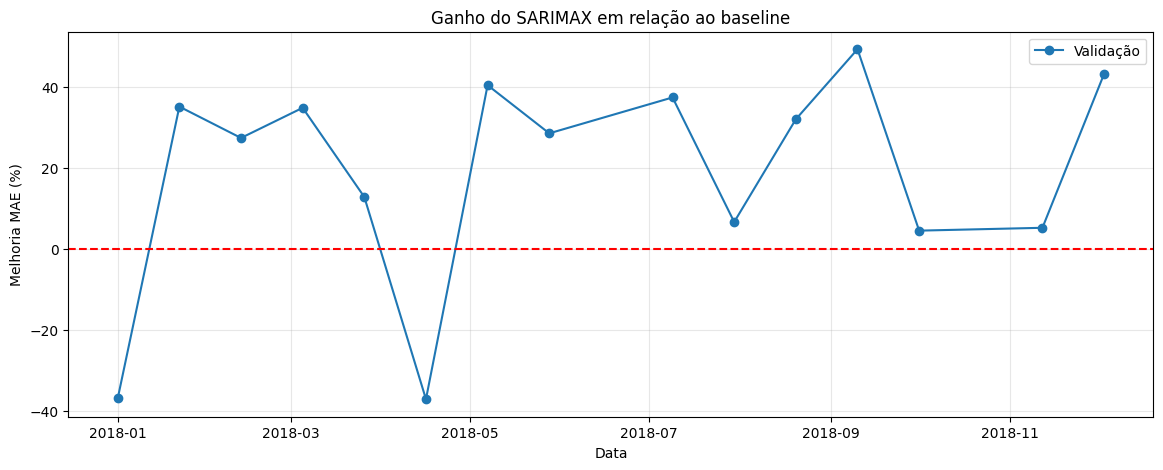

In [20]:
plt.figure(figsize=(14,5))

plt.plot(
    pd.to_datetime(order_val["inicio_previsao"]),
    order_val["melhora_mae_%"],
    marker="o",
    label="Validação"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.ylabel("Melhoria MAE (%)")
plt.xlabel("Data")
plt.title("Ganho do SARIMAX em relação ao baseline")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [21]:
# teste
order_teste = pd.read_csv('../results/walk_forward_parcial_temp_umi_prec_wind_101_teste.csv')
order_teste.head()

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_sarimax,rmse_sarimax,r2_sarimax,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2019-01-01 00:00:00+00:00,2019-01-01 23:00:00+00:00,2019-01,24,12.445241,18.217827,-0.157108,18.166667,24.262454,-1.052345,31.494087,24.913500
1,504,2019-01-22 00:00:00+00:00,2019-01-22 23:00:00+00:00,2019-01,24,8.019370,9.570993,-0.370098,12.500000,14.753531,-2.255589,35.845036,35.127438
2,1008,2019-02-12 00:00:00+00:00,2019-02-12 23:00:00+00:00,2019-02,24,4.570114,5.634869,-0.167657,4.708333,5.820223,-0.245738,2.935640,3.184661
3,1512,2019-03-05 00:00:00+00:00,2019-03-05 23:00:00+00:00,2019-03,22,6.161342,7.831001,0.172491,7.363636,10.045352,-0.361659,16.327460,22.043533
4,2016,2019-03-26 00:00:00+00:00,2019-03-26 23:00:00+00:00,2019-03,24,8.616169,11.246244,-1.225487,8.250000,10.916349,-1.096838,-4.438406,-3.022033


In [22]:
mae_medio = order_teste["mae_sarimax"].mean()
rmse_medio = order_teste["rmse_sarimax"].mean()
r2_medio = order_teste["r2_sarimax"].mean()

print(f"MAE médio  : {mae_medio:.3f}")
print(f"RMSE médio : {rmse_medio:.3f}")
print(f"R² médio   : {r2_medio:.3f}")

MAE médio  : 7.306
RMSE médio : 9.487
R² médio   : -0.437


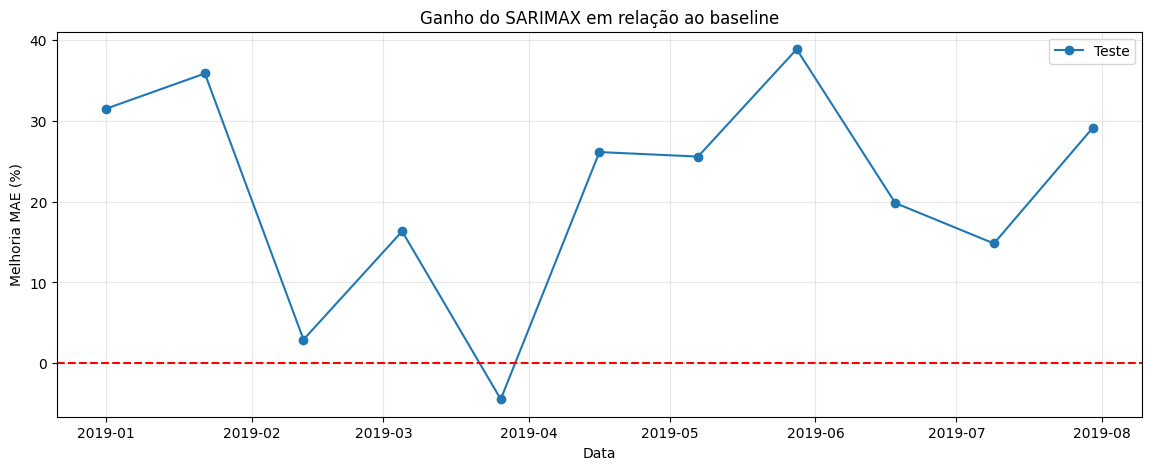

In [23]:
plt.figure(figsize=(14,5))

plt.plot(
    pd.to_datetime(order_teste["inicio_previsao"]),
    order_teste["melhora_mae_%"],
    marker="o",
    label="Teste"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.ylabel("Melhoria MAE (%)")
plt.xlabel("Data")
plt.title("Ganho do SARIMAX em relação ao baseline")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

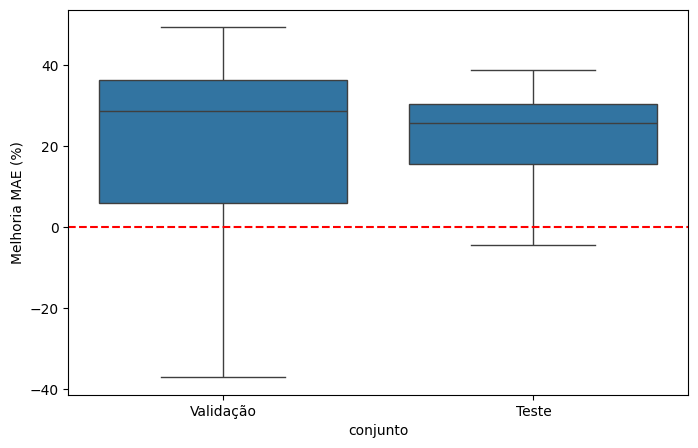

In [24]:
dados = pd.concat([
    order_val.assign(conjunto="Validação"),
    order_teste.assign(conjunto="Teste")
])

plt.figure(figsize=(8,5))

sns.boxplot(
    data=dados,
    x="conjunto",
    y="melhora_mae_%"
)

plt.axhline(0,color="red",ls="--")

plt.ylabel("Melhoria MAE (%)")
plt.show()

In [25]:
ganho_mae_val = 100 * (
    order_val["mae_baseline"].mean()
    - order_val["mae_sarimax"].mean()
) / order_val["mae_baseline"].mean()

ganho_mae_teste = 100 * (
    order_teste["mae_baseline"].mean()
    - order_teste["mae_sarimax"].mean()
) / order_teste["mae_baseline"].mean()

print(f"Ganho global validação: {ganho_mae_val:.2f}%")
print(f"Ganho global teste: {ganho_mae_teste:.2f}%")

Ganho global validação: 23.23%
Ganho global teste: 25.06%


In [26]:
resumo = pd.DataFrame({
    "conjunto": ["Validação", "Teste"],
    "ganho_mae_medio_%": [
        order_val["melhora_mae_%"].mean(),
        order_teste["melhora_mae_%"].mean()
    ],
    "ganho_rmse_medio_%": [
        order_val["melhora_rmse_%"].mean(),
        order_teste["melhora_rmse_%"].mean()
    ]
})

resumo.round(2)

,conjunto,ganho_mae_medio_%,ganho_rmse_medio_%
0,Validação,18.91,21.01
1,Teste,21.50,20.82
